# Short Leases Search Analysis

This notebook analysis the geographic areas that generate the most searches for short leases.

---
## 1. Setup and Imports

First, we import all necessary libraries and configure our environment.

In [1]:
# Cell 1 - Setup & Imports
import os
from pathlib import Path
from datetime import datetime
from dotenv import load_dotenv
import pandas as pd
import matplotlib.pyplot as plt
from pymongo import MongoClient
from shapely.geometry import shape, Point
from shapely.prepared import prep
from shapely.strtree import STRtree
from pyproj import Transformer
from tqdm.notebook import tqdm
import json


---
## 2. Configuration

Load connection details from the `.env` file and set up paths.

In [18]:
env_path = Path("../.env")
load_dotenv(env_path)

MONGO_URI = os.getenv("MONGO_URI_NOTEBOOK")
MONGO_DATABASE = os.getenv("MONGO_DATABASE")
TODAY = datetime(2026, 3, 10)
SHORT_LEASE_THRESHOLD = 80  # years


---
## 3. Connect to MongoDB

Establish a connection to the local MongoDB instance and verify the collection exists.

In [19]:
client = MongoClient(MONGO_URI)
db = client[MONGO_DATABASE]
collection_ext = db["leasesext"]
collection_views = db["leaseviewstats"]

print(f"Connected to database: {MONGO_DATABASE}")
print(f"leaseviewstats count: {collection_views.count_documents({})}")
print(f"leasesext count: {collection_ext.count_documents({})}")


Connected to database: leases
leaseviewstats count: 18404
leasesext count: 6718668


---
## 4. Load Districts GeoJSON

Load the UK districts boundaries from the GeoJSON file. The districts are in British National Grid (EPSG:27700), so we'll need to transform the coordinates.

In [20]:
with open("data/districts.geojson", "r") as f:
    districts_geojson = json.load(f)
print(f"Loaded {len(districts_geojson['features'])} districts")


Loaded 361 districts


---
## 5. Transform District Coordinates

The districts are in British National Grid (EPSG:27700), but our lease location data is likely in WGS84 (EPSG:4326). We need to transform the district boundaries to WGS84 for proper spatial matching.
Also, Create a spatial index (R-tree) for efficient point-in-polygon queries.

In [21]:
transformer = Transformer.from_crs("EPSG:27700", "EPSG:4326", always_xy=True)

def transform_polygon(coords):
    return [list(transformer.transform(x, y)) for x, y in coords]

def transform_geometry(geom):
    if geom['type'] == 'Polygon':
        return {'type': 'Polygon', 'coordinates': [transform_polygon(ring) for ring in geom['coordinates']]}
    elif geom['type'] == 'MultiPolygon':
        return {'type': 'MultiPolygon', 'coordinates': [[transform_polygon(ring) for ring in poly] for poly in geom['coordinates']]}
    return geom

districts = []
for feature in districts_geojson['features']:
    transformed = transform_geometry(feature['geometry'])
    geom = shape(transformed)
    districts.append({
        'code': feature['properties']['LAD24CD'],
        'name': feature['properties']['LAD24NM'],
        'geometry': geom,
        'prepared': prep(geom)
    })

geometries = [d['geometry'] for d in districts]
spatial_index = STRtree(geometries)
print(f"Built spatial index for {len(districts)} districts")


Built spatial index for 361 districts


---
## 6. Helper Functions

Define functions for district lookup and expiry date parsing.

In [22]:
def calculate_years_remaining(expiry_date):
    if expiry_date is None:
        return None
    return (expiry_date - TODAY).days / 365.25

def find_district(lon, lat):
    point = Point(lon, lat)
    # STRtree.query returns indices in newer Shapely versions
    candidate_indices = spatial_index.query(point)
    for idx in candidate_indices:
        if districts[idx]['prepared'].contains(point):
            return districts[idx]['code'], districts[idx]['name']
    return None, None


---
## 7. Process View Stats

Fetch view stats and join with lease data

In [23]:
print("Fetching view statistics...")
view_stats = list(collection_views.find({}, {"uniqueId": 1, "viewCount": 1}))
print(f"Found {len(view_stats)} view records")

# Create lookup dictionary
uid_to_views = {v['uniqueId']: v['viewCount'] for v in view_stats}
uids = list(uid_to_views.keys())
print(f"Unique lease IDs with views: {len(uids)}")


Fetching view statistics...
Found 18405 view records
Unique lease IDs with views: 18405


---
## 8. Process Viewed Leases

Query leases with location and expiry data

In [25]:
# Cell 8 - 
BATCH_SIZE = 10000
district_views = {}

print("Processing leases with view data...")
total_processed = 0
short_lease_count = 0

# Process in batches
for i in tqdm(range(0, len(uids), BATCH_SIZE), desc="Batch processing"):
    batch_uids = uids[i:i + BATCH_SIZE]
    
    query = {
        "uid": {"$in": batch_uids},
        "loc": {"$exists": True, "$ne": None},
        "exp": {"$exists": True, "$ne": None}
    }
    
    cursor = collection_ext.find(query, {"uid": 1, "loc": 1, "exp": 1})
    
    for doc in cursor:
        total_processed += 1
        uid = doc['uid']
        exp = doc['exp']
        
        years_remaining = calculate_years_remaining(exp)
        if years_remaining is None or years_remaining >= SHORT_LEASE_THRESHOLD:
            continue
        short_lease_count += 1
        loc = doc['loc']
        lon, lat = loc['coordinates']
        
        code, name = find_district(lon, lat)
        if code:
            view_count = uid_to_views.get(uid, 0)
            if code not in district_views:
                district_views[code] = {'name': name, 'total_views': 0, 'lease_count': 0}
            district_views[code]['total_views'] += view_count
            district_views[code]['lease_count'] += 1

print(f"\nProcessed {total_processed} leases with location and expiry")
print(f"Short leases (<{SHORT_LEASE_THRESHOLD} years): {short_lease_count}")
print(f"Districts with data: {len(district_views)}")


Processing leases with view data...


Batch processing:   0%|          | 0/2 [00:00<?, ?it/s]


Processed 23465 leases with location and expiry
Short leases (<80 years): 4478
Districts with data: 267


---
## 9. Create Results DataFrame

Calculate percentages and create a DataFrame with results.

In [26]:
results = []
for code, data in district_views.items():
    results.append({
        'district_code': code,
        'district_name': data['name'],
        'total_views': data['total_views'],
        'short_lease_count': data['lease_count'],
        'avg_views_per_lease': data['total_views'] / data['lease_count'] if data['lease_count'] > 0 else 0
    })

df = pd.DataFrame(results)
df = df.sort_values('total_views', ascending=False).reset_index(drop=True)
print(f"\nTop 20 Districts by Short Lease Search Views:")
print(df.head(20).to_string(index=False))


Top 20 Districts by Short Lease Search Views:
district_code                       district_name  total_views  short_lease_count  avg_views_per_lease
    E08000022                      North Tyneside          325                325             1.000000
    E08000025                          Birmingham          275                238             1.155462
    E09000007                              Camden          218                104             2.096154
    E06000058 Bournemouth, Christchurch and Poole          149                122             1.221311
    E07000224                                Arun          148                 52             2.846154
    E09000012                             Hackney          142                 34             4.176471
    E09000033                         Westminster          106                 87             1.218391
    E06000035                              Medway          100                 94             1.063830
    E09000008             

---
## 10. Visualise Data

Bar Chart: Top 20 Districts by Total Views

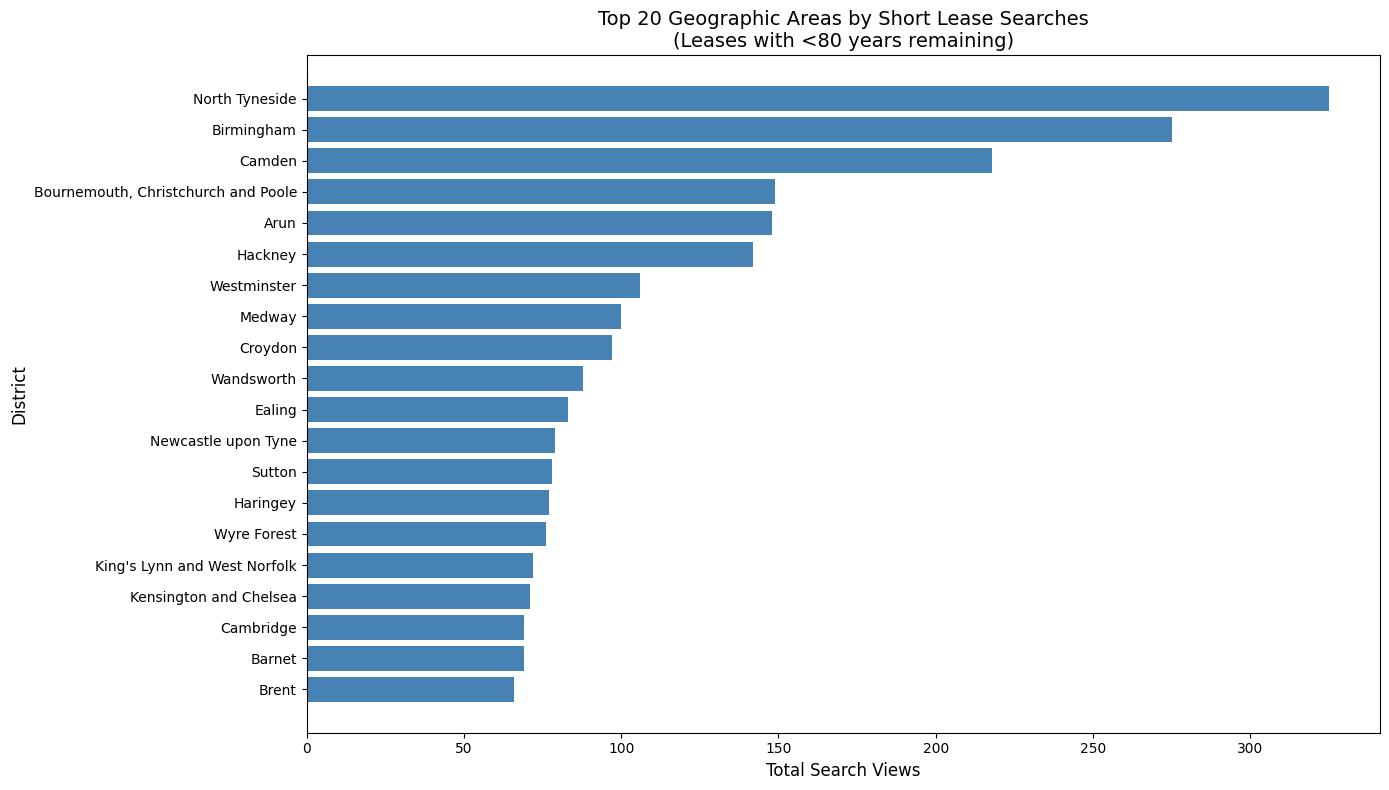

In [27]:
top_20 = df.head(20)

plt.figure(figsize=(14, 8))
bars = plt.barh(range(len(top_20)), top_20['total_views'], color='steelblue')
plt.yticks(range(len(top_20)), top_20['district_name'])
plt.xlabel('Total Search Views', fontsize=12)
plt.ylabel('District', fontsize=12)
plt.title(f'Top 20 Geographic Areas by Short Lease Searches\n(Leases with <{SHORT_LEASE_THRESHOLD} years remaining)', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
# plt.savefig('short_lease_search_by_district.png', dpi=150, bbox_inches='tight')
plt.show()


In [28]:
# Export Results
# df.to_csv('short_lease_search_analysis.csv', index=False)
print(f"Results exported to short_lease_search_analysis.csv")

Results exported to short_lease_search_analysis.csv


---
## 11. Cleanup

Close the MongoDB connection.

In [29]:
# Cell 12 - Cleanup
client.close()
print("MongoDB connection closed")


MongoDB connection closed
